# 01 — Explorative Datenanalyse (MovieLens Small)

**Person C** | Aufgabe C3  
Datensatz: `data/small/` (MovieLens 100k)

Inhalte:
- Verteilung der Bewertungen (Histogramm)
- Top-20 meistbewertete Filme
- Anzahl Bewertungen pro User (Histogramm)
- Sparsity der User-Item-Matrix

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Pfade relativ zum Repo-Root
ROOT = Path("..")
DATA = ROOT / "data" / "small"
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
ratings = pd.read_csv(DATA / "ratings.csv")
movies  = pd.read_csv(DATA / "movies.csv")

print(f"ratings: {ratings.shape[0]:,} Zeilen, {ratings.shape[1]} Spalten")
print(f"movies:  {movies.shape[0]:,} Zeilen, {movies.shape[1]} Spalten")
ratings.head()

ratings: 100,836 Zeilen, 4 Spalten
movies:  9,742 Zeilen, 3 Spalten


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 1 — Verteilung der Bewertungen

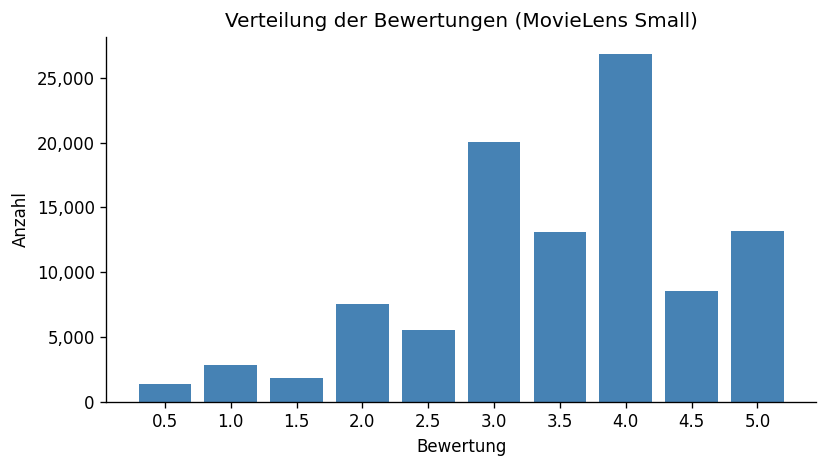

Gespeichert: ../results/figures/rating_distribution.png


In [3]:
rating_counts = ratings["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rating_counts.index, rating_counts.values, width=0.4, color="steelblue")
ax.set_xlabel("Bewertung")
ax.set_ylabel("Anzahl")
ax.set_title("Verteilung der Bewertungen (MovieLens Small)")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(rating_counts.index)

fig.tight_layout()
fig.savefig(FIGURES / "rating_distribution.png")
plt.show()
print(f"Gespeichert: {FIGURES / 'rating_distribution.png'}")

## 2 — Top-20 meistbewertete Filme

In [4]:
top20 = (
    ratings.groupby("movieId", as_index=False)
           .agg(num_ratings=("rating", "count"),
                avg_rating=("rating", "mean"))
           .merge(movies[["movieId", "title"]], on="movieId")
           .sort_values("num_ratings", ascending=False)
           .head(20)
           .reset_index(drop=True)
)
top20.index += 1  # Rang 1-20
top20[["title", "num_ratings", "avg_rating"]].style.format(
    {"num_ratings": "{:,}", "avg_rating": "{:.2f}"}
)

,title,num_ratings,avg_rating
1,Forrest Gump (1994),329,4.16
2,"Shawshank Redemption, The (1994)",317,4.43
3,Pulp Fiction (1994),307,4.20
4,"Silence of the Lambs, The (1991)",279,4.16
5,"Matrix, The (1999)",278,4.19
6,Star Wars: Episode IV - A New Hope (1977),251,4.23
7,Jurassic Park (1993),238,3.75
8,Braveheart (1995),237,4.03
9,Terminator 2: Judgment Day (1991),224,3.97
10,Schindler's List (1993),220,4.22


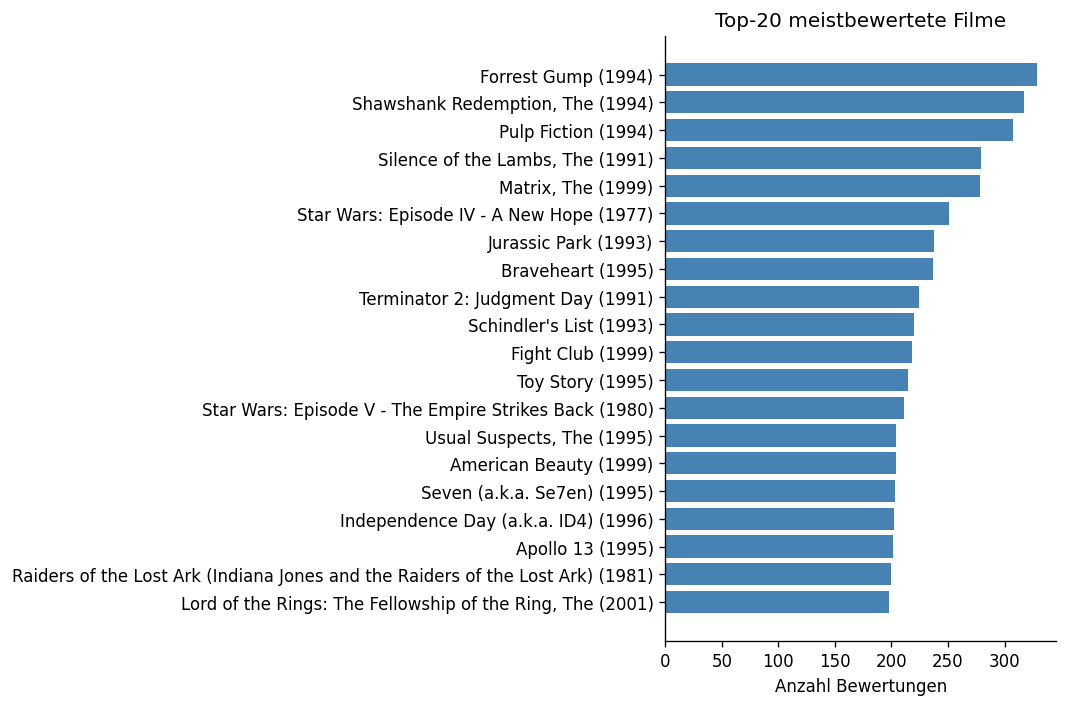

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20["title"][::-1], top20["num_ratings"][::-1], color="steelblue")
ax.set_xlabel("Anzahl Bewertungen")
ax.set_title("Top-20 meistbewertete Filme")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
fig.savefig(FIGURES / "top20_most_rated.png")
plt.show()

## 3 — Anzahl Bewertungen pro User

Durchschnitt: 165.3 Bewertungen/User
Median:       70
Min / Max:    20 / 2698


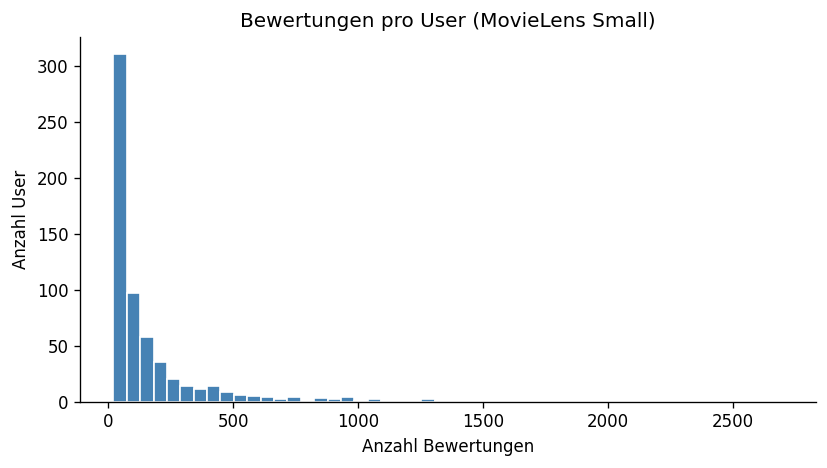

Gespeichert: ../results/figures/ratings_per_user.png


In [6]:
ratings_per_user = ratings.groupby("userId")["rating"].count()

print(f"Durchschnitt: {ratings_per_user.mean():.1f} Bewertungen/User")
print(f"Median:       {ratings_per_user.median():.0f}")
print(f"Min / Max:    {ratings_per_user.min()} / {ratings_per_user.max()}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ratings_per_user, bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Anzahl Bewertungen")
ax.set_ylabel("Anzahl User")
ax.set_title("Bewertungen pro User (MovieLens Small)")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
fig.savefig(FIGURES / "ratings_per_user.png")
plt.show()
print(f"Gespeichert: {FIGURES / 'ratings_per_user.png'}")

## 4 — Sparsity der User-Item-Matrix

In [7]:
n_ratings = len(ratings)
n_users   = ratings["userId"].nunique()
n_movies  = ratings["movieId"].nunique()
n_possible = n_users * n_movies
sparsity  = 1 - (n_ratings / n_possible)

print(f"Bewertungen gesamt:      {n_ratings:>10,}")
print(f"Unique User:             {n_users:>10,}")
print(f"Unique Filme:            {n_movies:>10,}")
print(f"Mögliche Einträge:       {n_possible:>10,}")
print(f"Sparsity:                {sparsity:>10.2%}")

Bewertungen gesamt:         100,836
Unique User:                    610
Unique Filme:                 9,724
Mögliche Einträge:        5,931,640
Sparsity:                    98.30%
